## 6. Clusterability and Clustering Structure Questions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

**Load cleaned data and define analysis variables**

In [2]:
df = pd.read_csv("cleaned_Beer_data.csv")
df.head()

,Name,Style,Brewery,Beer Name (Full),Description,ABV,Min IBU,Max IBU,Astringency,Body,...,Fruits,Hoppy,Spices,Malty,review_aroma,review_appearance,review_palate,review_taste,review_overall,number_of_reviews
0,Amber,Altbier,Alaskan Brewing Co.,Alaskan Brewing Co. Alaskan Amber,"Notes:Richly malty and long on the palate, wit...",-0.481696,0.28848,0.515791,-0.337764,-0.544620,...,-0.171238,0.528815,-0.435553,0.893892,3.498994,3.636821,3.556338,3.643863,3.847082,497
1,Double Bag,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Double Bag,"Notes:This malty, full-bodied double alt is al...",0.264397,0.28848,0.515791,-0.433834,0.419002,...,-0.449949,-0.194896,-0.267152,0.217253,3.798337,3.846154,3.904366,4.024948,4.034304,481
2,Long Trail Ale,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Long Trail Ale,Notes:Long Trail Ale is a full-bodied amber al...,-0.599501,0.28848,0.515791,-0.241694,-0.351895,...,-0.883498,0.430127,-0.603954,-0.334083,3.409814,3.667109,3.600796,3.631300,3.830239,377
3,Doppelsticke,Altbier,Uerige Obergärige Hausbrauerei GmbH / Zum Uerige,Uerige Obergärige Hausbrauerei GmbH / Zum Ueri...,Notes:,0.774882,0.28848,0.515791,-0.337764,0.341912,...,0.324247,-0.030416,-0.098752,1.094378,4.148098,4.033967,4.150815,4.205163,4.005435,368
4,Sleigh'r Dark Doüble Alt Ale,Altbier,Ninkasi Brewing Company,Ninkasi Brewing Company Sleigh'r Dark Doüble A...,Notes:Called 'Dark Double Alt' on the label.Se...,0.264397,0.28848,0.515791,0.815081,0.187733,...,-0.852530,0.331439,0.069649,0.492921,3.625000,3.973958,3.734375,3.765625,3.817708,96


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3197 entries, 0 to 3196
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               3197 non-null   object 
 1   Style              3197 non-null   object 
 2   Brewery            3197 non-null   object 
 3   Beer Name (Full)   3197 non-null   object 
 4   Description        3197 non-null   object 
 5   ABV                3197 non-null   float64
 6   Min IBU            3197 non-null   float64
 7   Max IBU            3197 non-null   float64
 8   Astringency        3197 non-null   float64
 9   Body               3197 non-null   float64
 10  Alcohol            3197 non-null   float64
 11  Bitter             3197 non-null   float64
 12  Sweet              3197 non-null   float64
 13  Sour               3197 non-null   float64
 14  Salty              3197 non-null   float64
 15  Fruits             3197 non-null   float64
 16  Hoppy              3197 

In [4]:
# Beer specification variables
specific_cols = ['ABV', 'Min IBU', 'Max IBU']

profile_features = [
    'Astringency', 'Body', 'Alcohol',
    'Bitter', 'Sweet', 'Sour', 'Salty',
    'Fruits', 'Hoppy', 'Spices', 'Malty'
]

# Main variables used to check clusterability
cluster_features = specific_cols + profile_features

X = df[cluster_features].copy()

X = X.select_dtypes(include=[np.number])
X.head()

,ABV,Min IBU,Max IBU,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty
0,-0.481696,0.28848,0.515791,-0.337764,-0.544620,-0.464895,0.412438,0.458897,-0.004066,-0.477041,-0.171238,0.528815,-0.435553,0.893892
1,0.264397,0.28848,0.515791,-0.433834,0.419002,0.054477,-0.130468,-0.095428,-0.479264,-0.477041,-0.449949,-0.194896,-0.267152,0.217253
2,-0.599501,0.28848,0.515791,-0.241694,-0.351895,-0.638019,0.218543,-0.445528,-0.619028,-0.477041,-0.883498,0.430127,-0.603954,-0.334083
3,0.774882,0.28848,0.515791,-0.337764,0.341912,0.804681,0.412438,1.246621,-0.423358,-0.008068,0.324247,-0.030416,-0.098752,1.094378
4,0.264397,0.28848,0.515791,0.815081,0.187733,0.516141,0.296101,-0.387178,-0.674933,-0.008068,-0.852530,0.331439,0.069649,0.492921


In [5]:
X.describe().round(3)

,ABV,Min IBU,Max IBU,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty
count,3197.000,3197.000,3197.000,3197.000,3197.000,3197.000,3197.000,3197.000,3197.000,3197.000,3197.000,3197.000,3197.000,3197.000
mean,0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.563,-1.600,-1.826,-1.587,-1.778,-0.984,-1.410,-1.700,-0.927,-0.477,-1.193,-1.346,-0.772,-1.888
25%,-0.600,-0.467,-0.655,-0.722,-0.660,-0.638,-0.751,-0.737,-0.619,-0.477,-0.822,-0.754,-0.604,-0.760
50%,-0.207,-0.089,-0.187,-0.242,-0.236,-0.349,-0.208,-0.125,-0.312,-0.477,-0.295,-0.261,-0.351,-0.058
75%,0.421,0.288,0.282,0.431,0.458,0.285,0.606,0.546,0.248,-0.008,0.665,0.496,0.196,0.693
max,20.016,3.310,2.857,6.195,4.967,7.037,4.407,5.973,7.012,22.034,4.226,4.312,6.974,4.102


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(3197, 14)

# t-SNE plots + clusterability check

In [7]:
perplexity_values = [5, 10, 20, 30, 40, 50]
random_states = [33, 437]

tsne_results = {}

for perp in perplexity_values:
    for rs in random_states:
        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            random_state=rs,
            init="random",
            learning_rate="auto",
            max_iter=1000
        )
        
        tsne_embedding = tsne.fit_transform(X_scaled)
        
        temp_df = df.copy()
        temp_df["tsne_x"] = tsne_embedding[:, 0]
        temp_df["tsne_y"] = tsne_embedding[:, 1]
        
        tsne_results[(perp, rs)] = temp_df

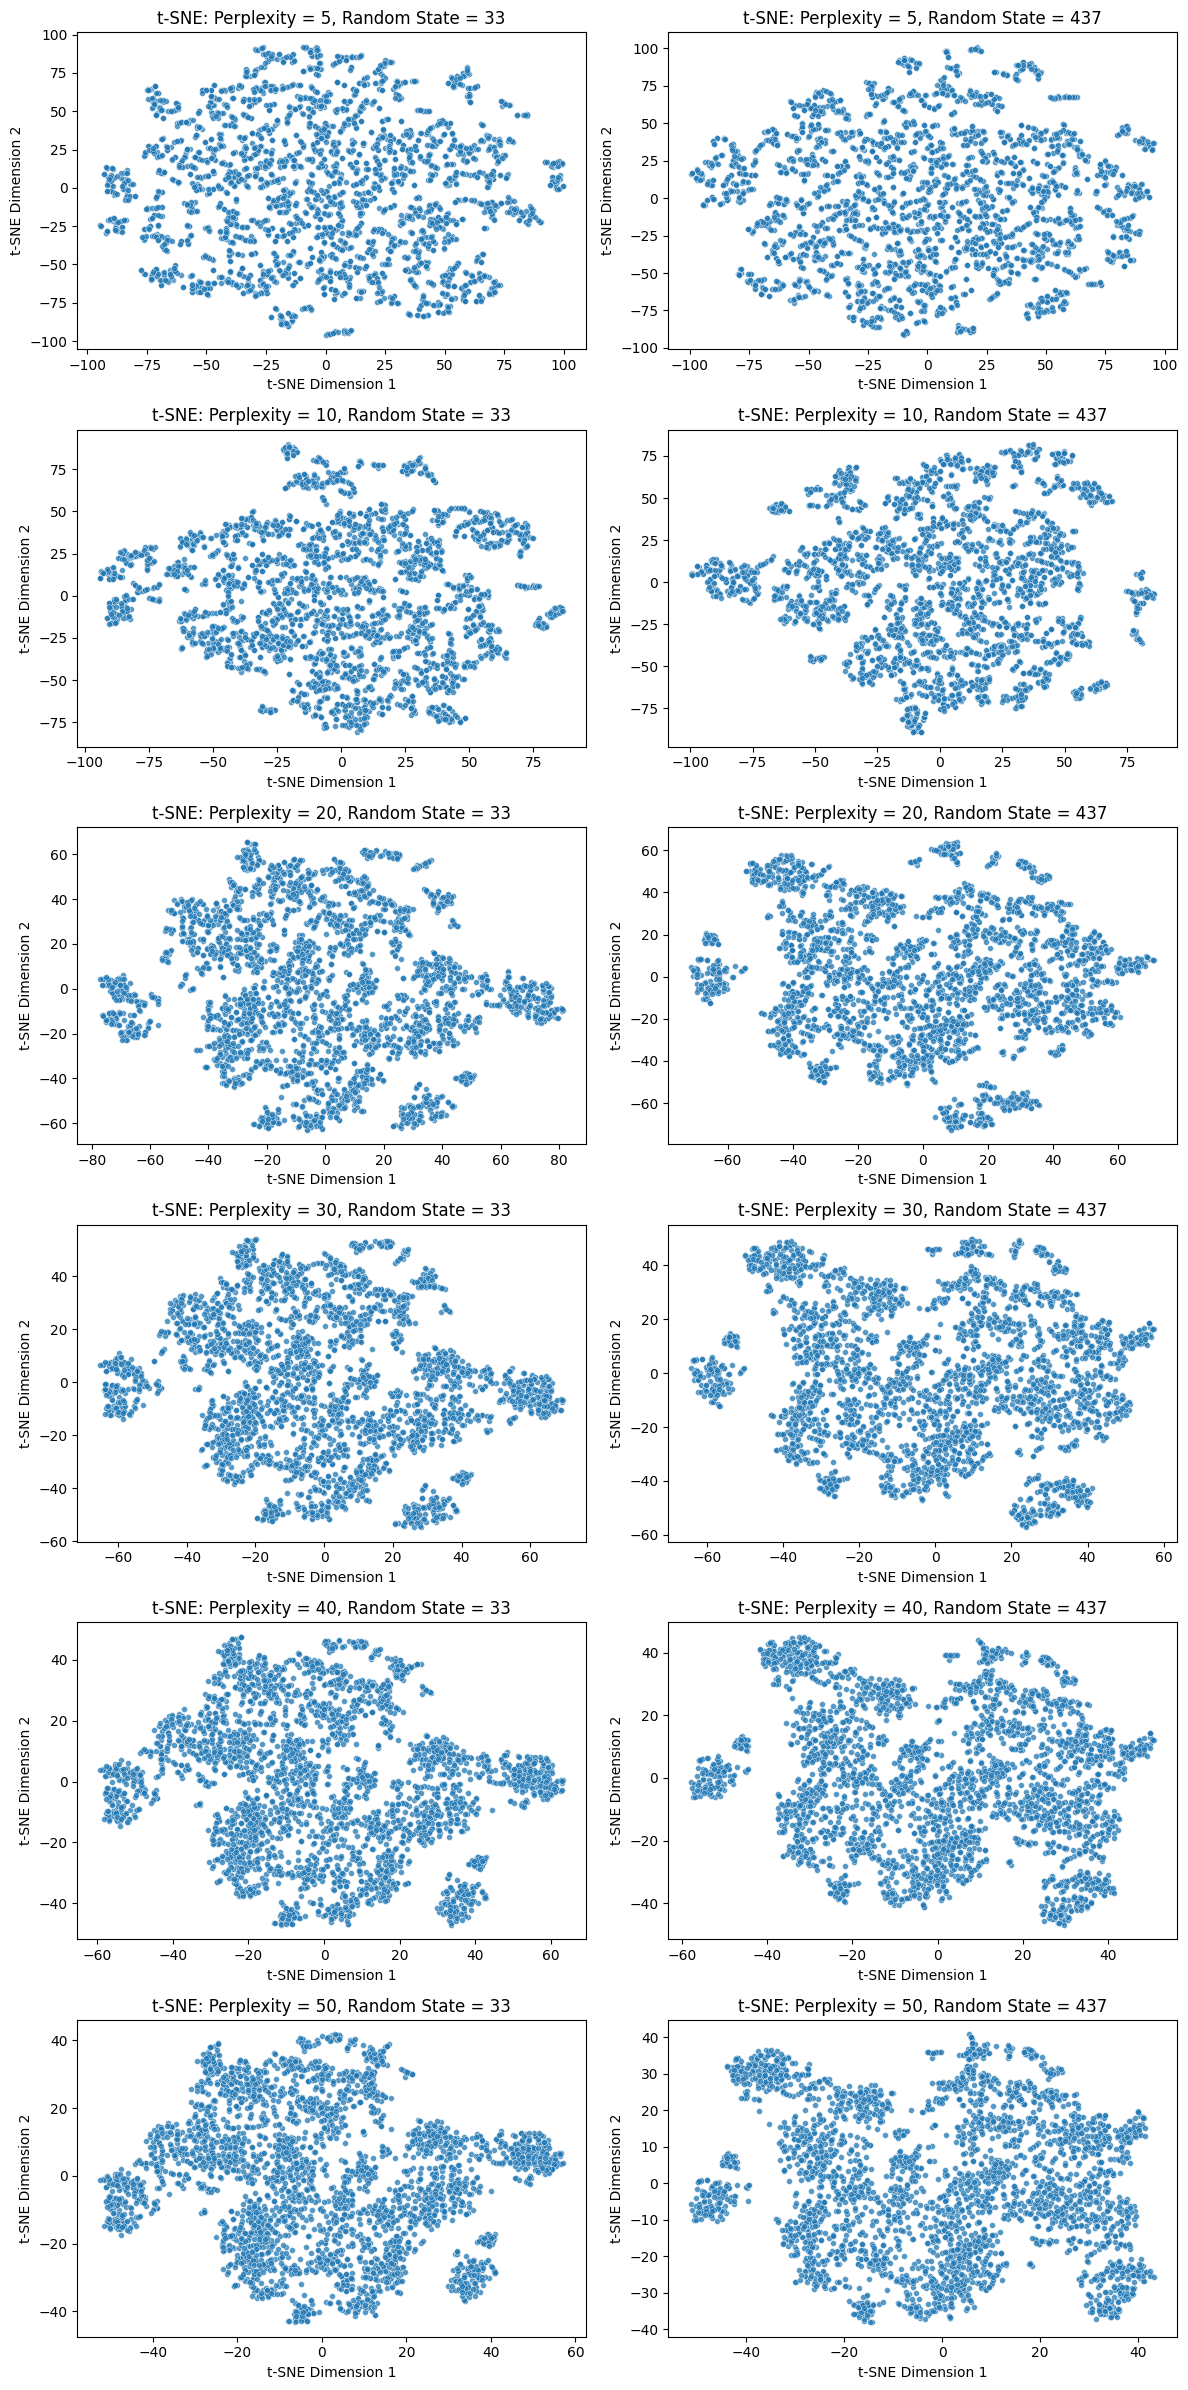

In [8]:
fig, axes = plt.subplots(len(perplexity_values), len(random_states), figsize=(12, 24))

for i, perp in enumerate(perplexity_values):
    for j, rs in enumerate(random_states):
        ax = axes[i, j]
        temp_df = tsne_results[(perp, rs)]
        
        sns.scatterplot(
            data=temp_df,
            x="tsne_x",
            y="tsne_y",
            s=18,
            alpha=0.75,
            ax=ax
        )
        
        ax.set_title(f"t-SNE: Perplexity = {perp}, Random State = {rs}")
        ax.set_xlabel("t-SNE Dimension 1")
        ax.set_ylabel("t-SNE Dimension 2")

plt.tight_layout()
plt.show()

**Representative t-SNE plot (I chose perplexity = 30 and random state = 33 here)**

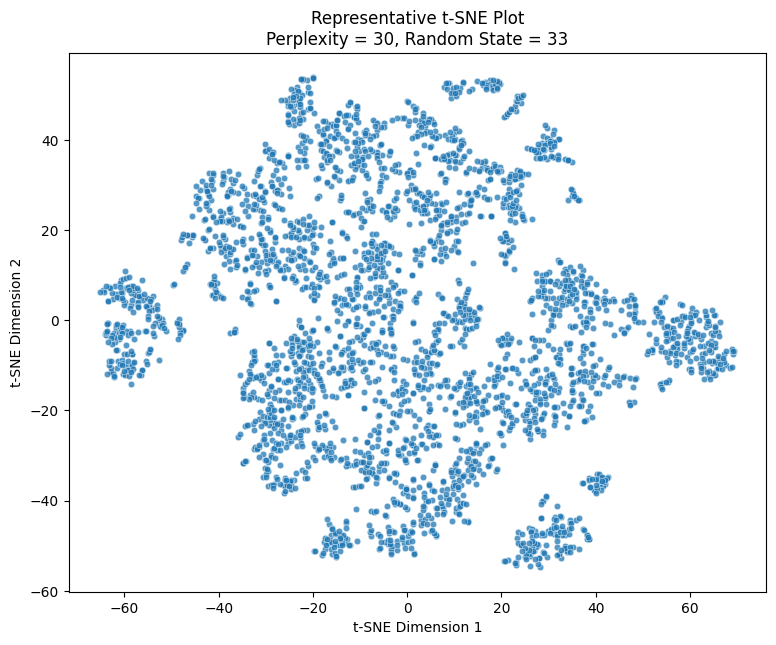

In [9]:
representative_perplexity = 30
representative_random_state = 33

df_tsne = tsne_results[(representative_perplexity, representative_random_state)].copy()

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df_tsne,
    x="tsne_x",
    y="tsne_y",
    s=22,
    alpha=0.75
)

plt.title(
    f"Representative t-SNE Plot\n"
    f"Perplexity = {representative_perplexity}, Random State = {representative_random_state}"
)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

Based on the t-SNE plots created using six different perplexity values and two random states each, the beer dataset appears to be clusterable. Across most of the t-SNE plots, the observations do not appear as one completely random, unstructured cloud. Instead, there are several visible dense regions, smaller separated groups, and gaps between some groups of observations. This repeated pattern across different perplexity values and random states suggests that the structure is not only caused by one specific t-SNE setting.

The clearest structure appears when the perplexity value is around 30 and 40. At very low perplexity values, especially perplexity 5, the plot looks more fragmented and noisy because t-SNE is emphasizing very local relationships. As the perplexity increases, the broader structure becomes easier to see. For this reason, a t-SNE plot with perplexity = 30 or perplexity = 40 would be a good representative plot because it shows both the larger grouping structure and some smaller subgroup patterns.

I think the plots suggest that the dataset has approximately 4 to 6 main underlying clusters, depending on how broadly we define a cluster. There appears to be one large central mass of observations, but this central region is not completely uniform. It seems to contain several denser subregions. In addition, there are smaller, more separated groups around the outside of the plot, especially near the left side, right side, upper-left area, and lower-right area in many of the higher-perplexity plots. Therefore, it may be reasonable to describe the dataset as having a few broad beer-profile regions, with some smaller subclusters inside or around them.

The shapes of the clusters are not perfectly spherical. Instead, many of the visible groups look irregular, curved, elongated, or partially connected. This is important because it suggests that the underlying beer profiles may not fit the ideal assumptions of centroid-based clustering methods like k-means, which usually work best when clusters are compact, spherical, and similarly sized. The t-SNE plots suggest that some clusters may be better understood as density-based or irregularly shaped groups.

The clusters are also not perfectly balanced in size. Some regions contain many beer observations, especially the large central structure, while other regions are much smaller and appear as compact side groups. This suggests that some beer profiles are much more common in the dataset, while other profiles represent smaller, more specialized groups.

There are also some clusters that are not well-separated. Although several outer groups have visible gaps from the main body, many observations in the center appear to gradually transition from one region into another. These overlapping or bridge-like areas suggest that some beers may share mixed characteristics and may not belong cleanly to only one cluster. For example, beers may vary gradually in bitterness, sweetness, maltiness, fruitiness, or alcohol level rather than falling into completely distinct categories.

Finally, there is some evidence of nested cluster relationships. The larger central region appears to contain smaller dense pockets, and some of the larger visible regions appear to break into subgroups as the perplexity changes. This suggests that the beer data may have both broad groups and smaller subgroups. In other words, there may be large categories of beer profiles, but within those broad categories, there may be more detailed subtypes.

# Clustering structure and attribute association

**Color-code the representative t-SNE plot by each beer attribute**

In [11]:
def plot_tsne_by_numeric_attribute(data, attribute):
    plt.figure(figsize=(9, 7))
    
    scatter = plt.scatter(
        data["tsne_x"],
        data["tsne_y"],
        c=data[attribute],
        s=22,
        alpha=0.75
    )
    
    plt.colorbar(scatter, label=attribute)
    plt.title(f"Representative t-SNE Plot Colored by {attribute}")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

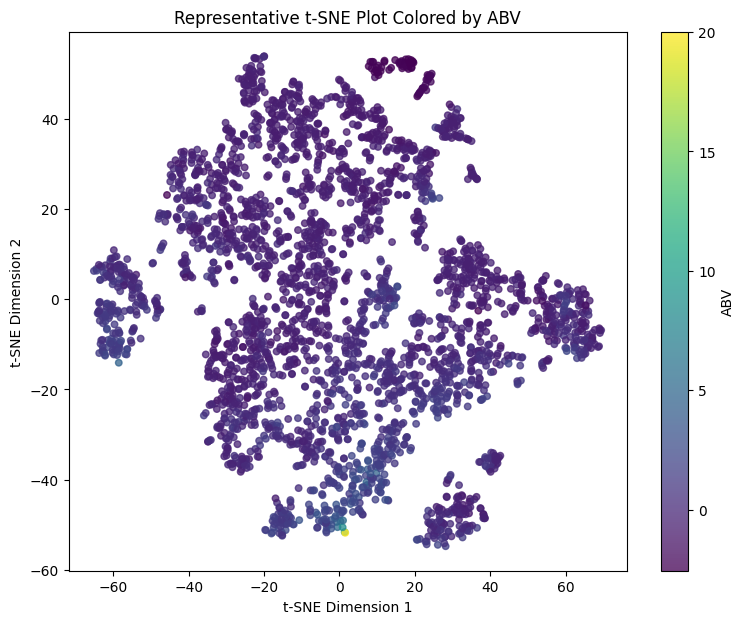

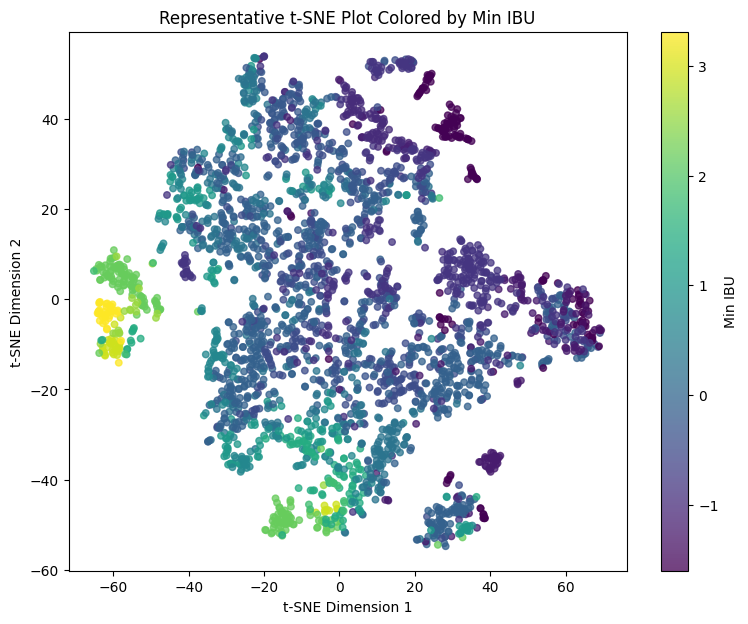

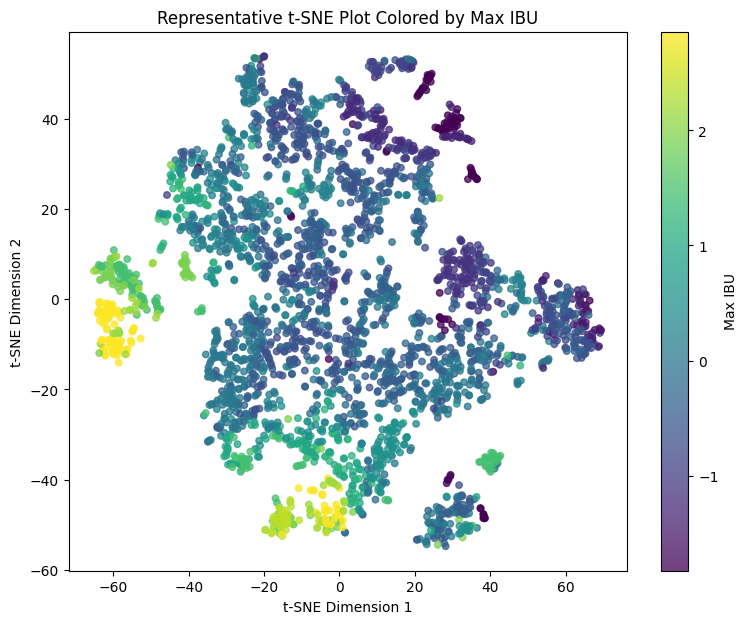

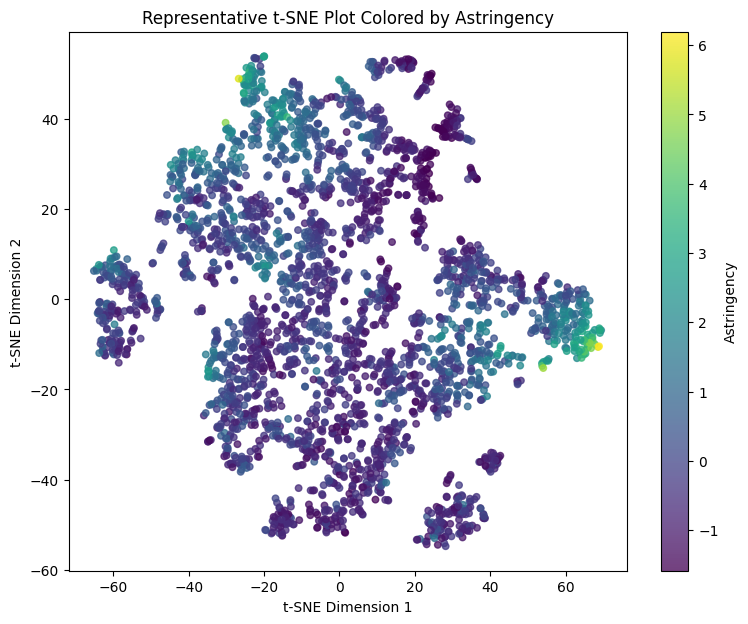

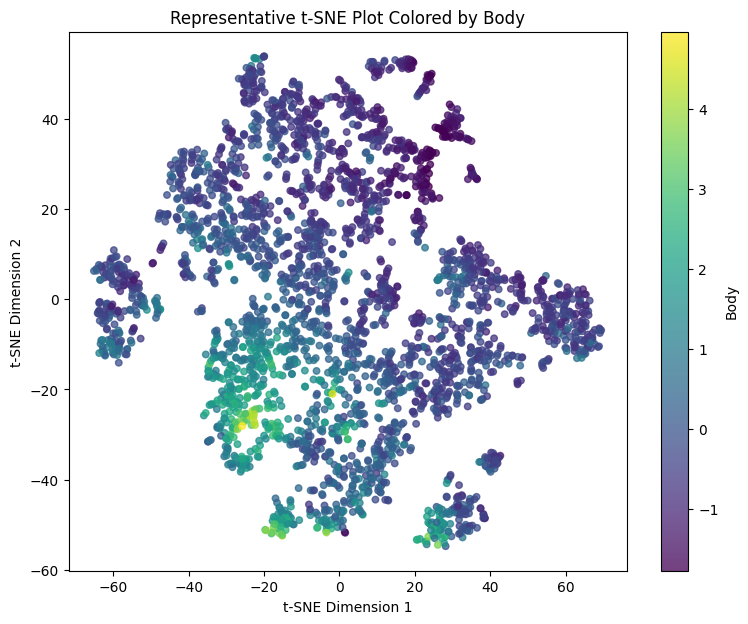

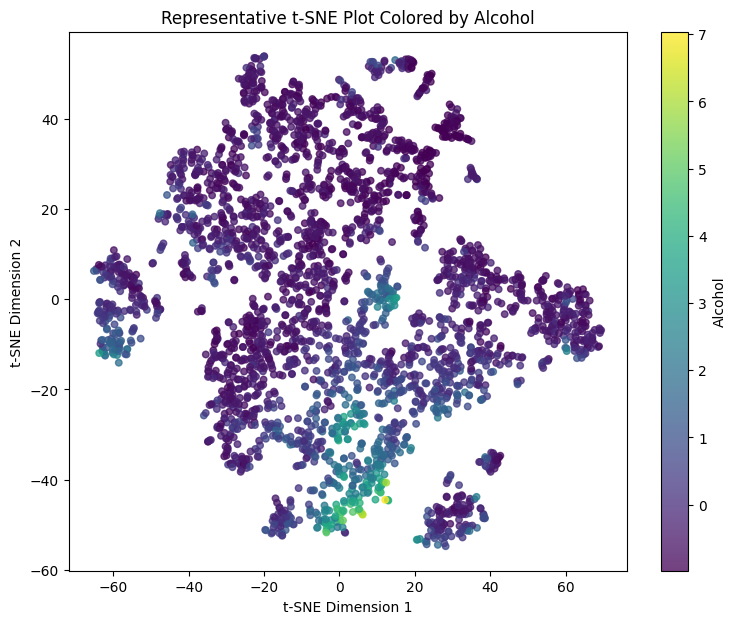

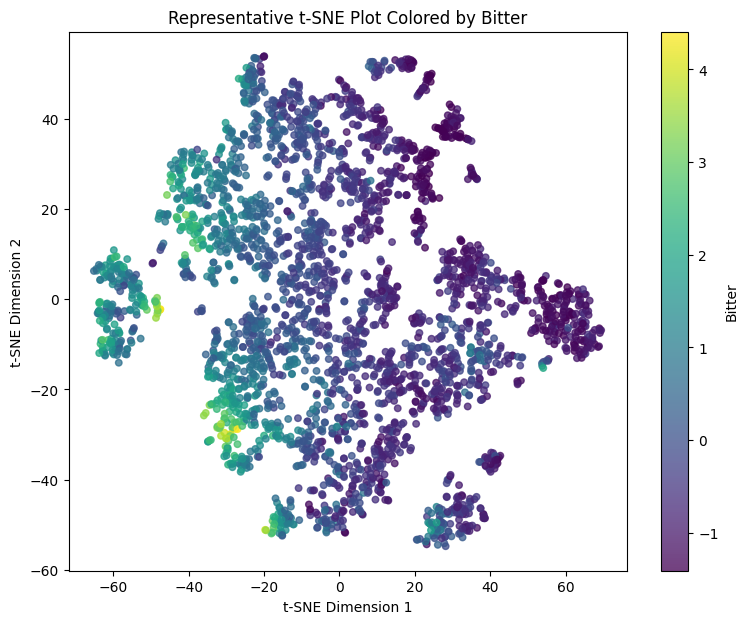

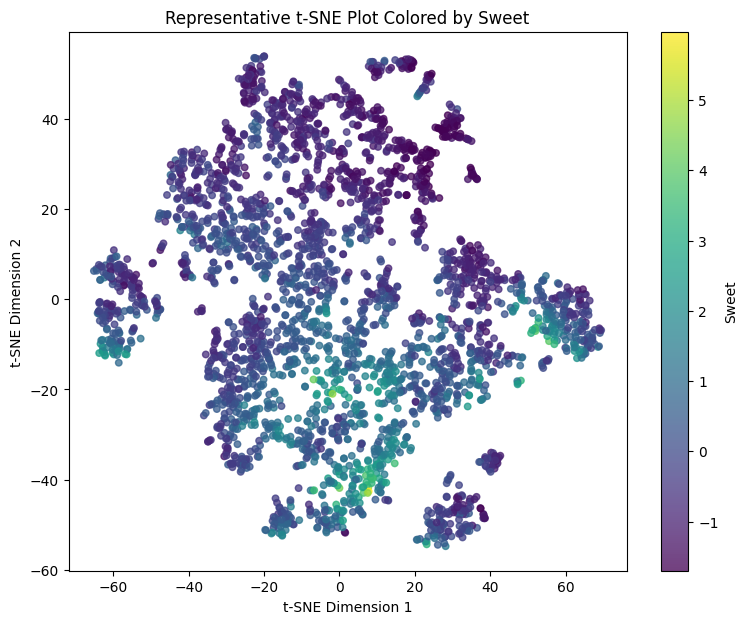

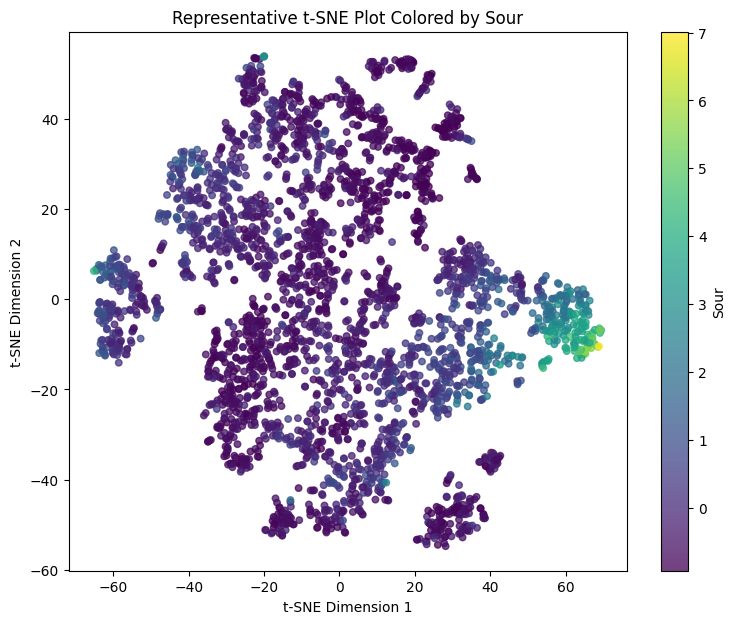

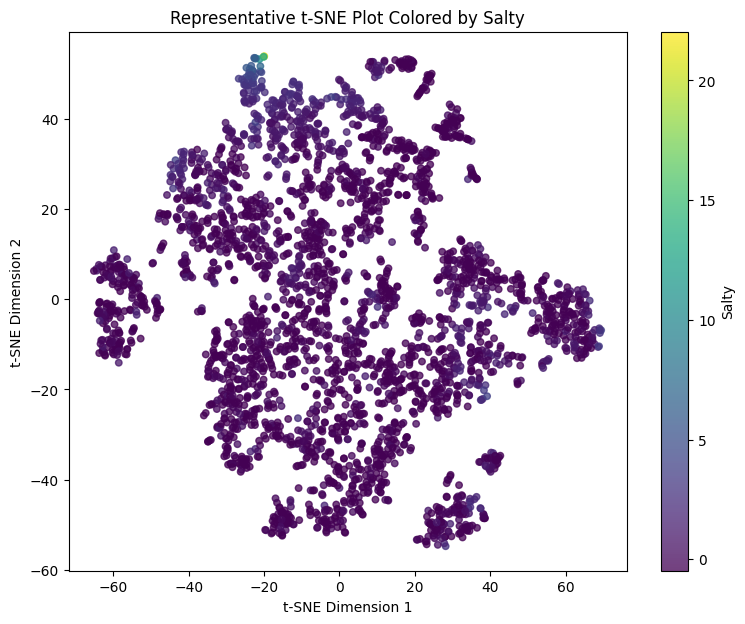

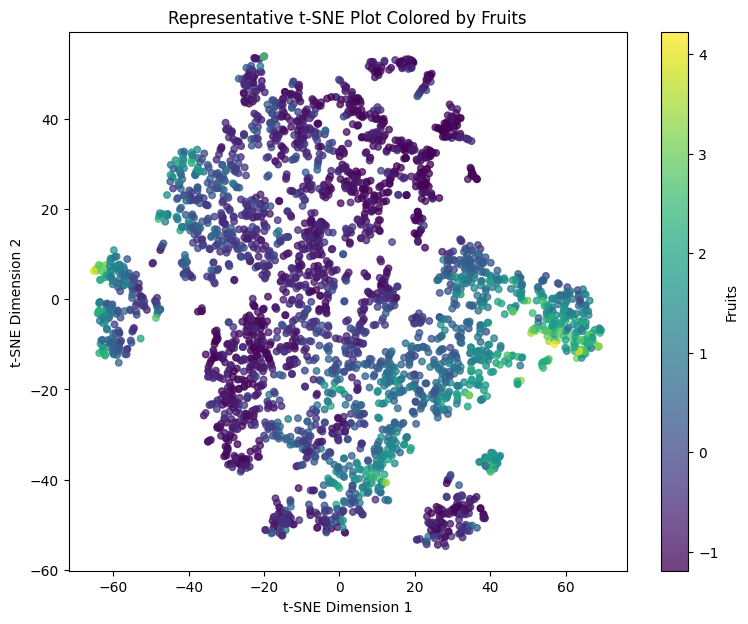

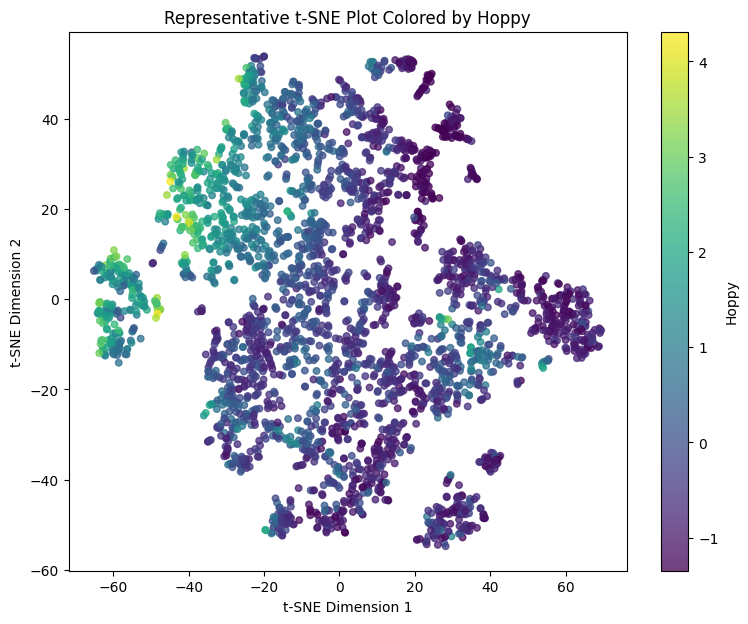

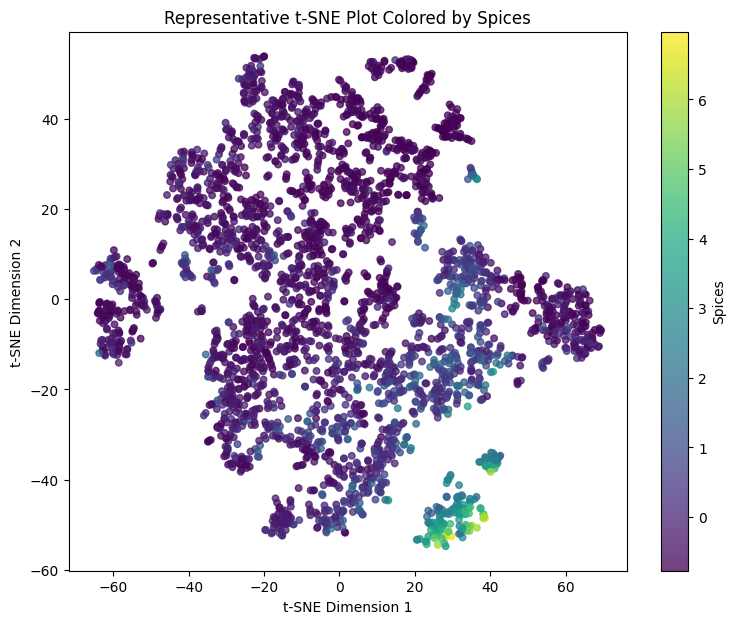

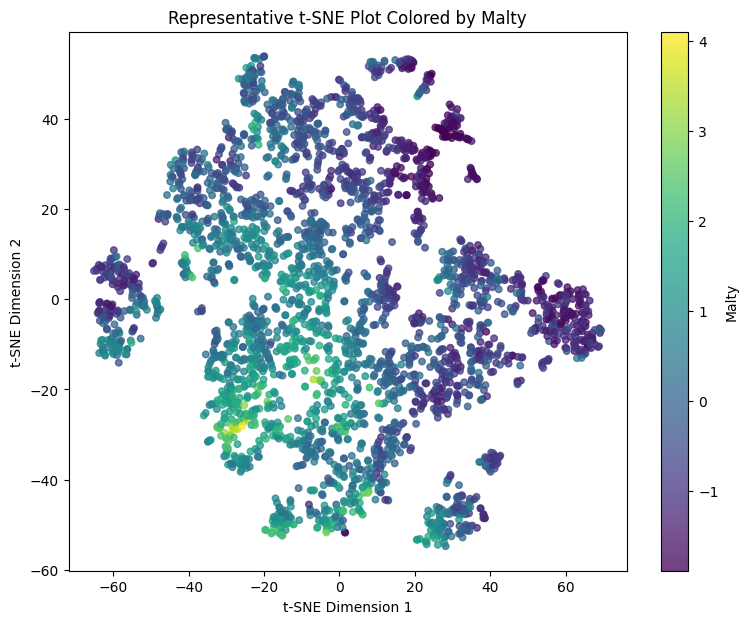

In [12]:
for col in cluster_features:
    plot_tsne_by_numeric_attribute(df_tsne, col)

**Check rating variables**

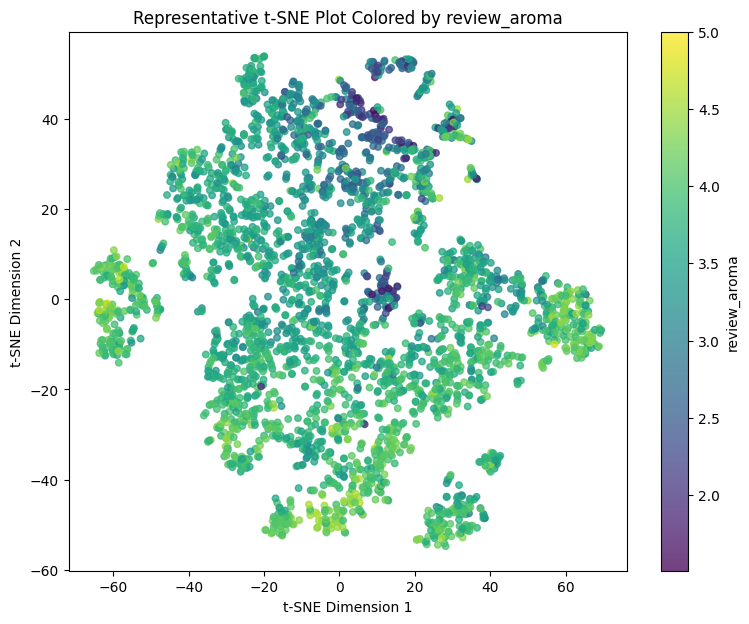

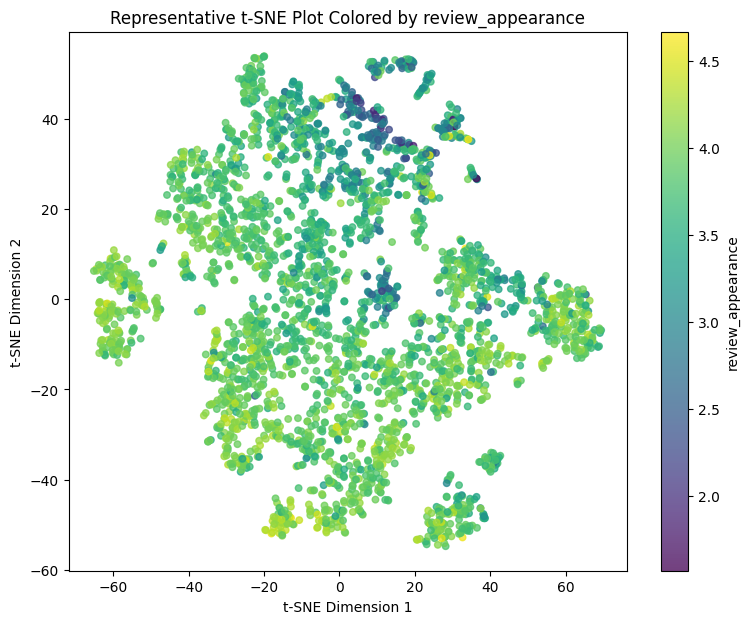

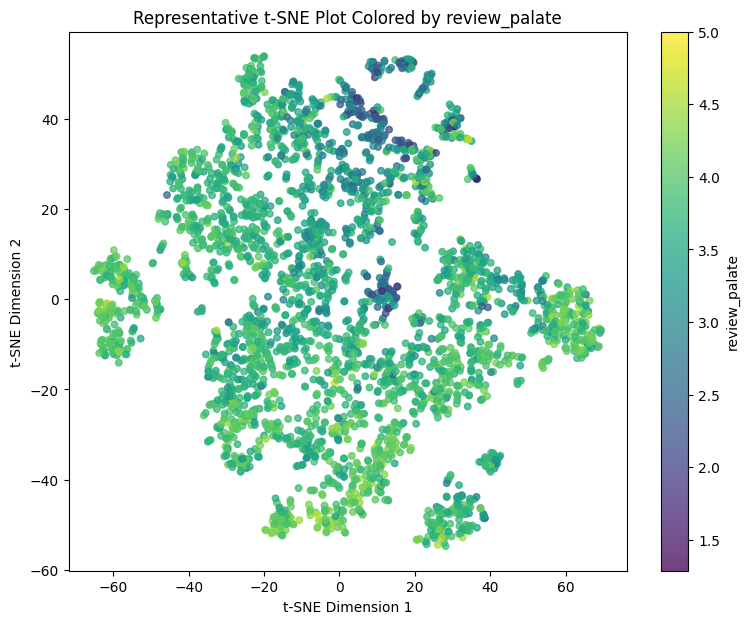

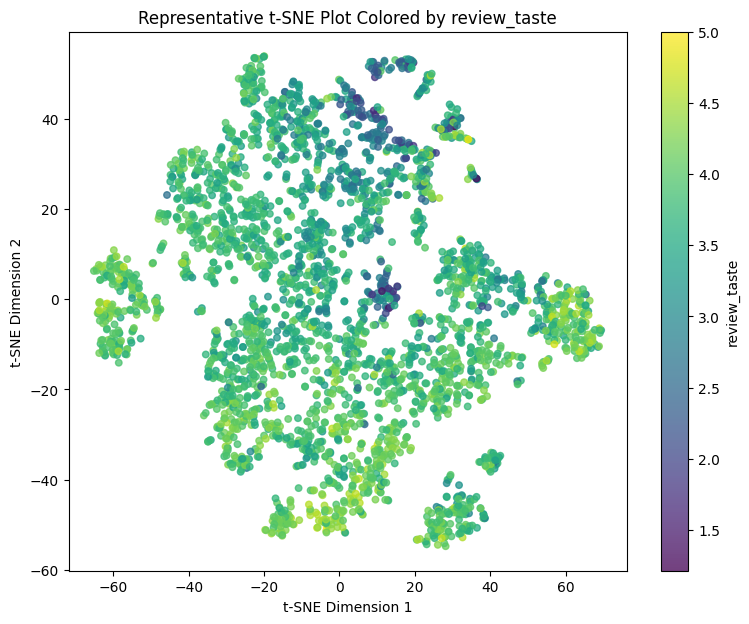

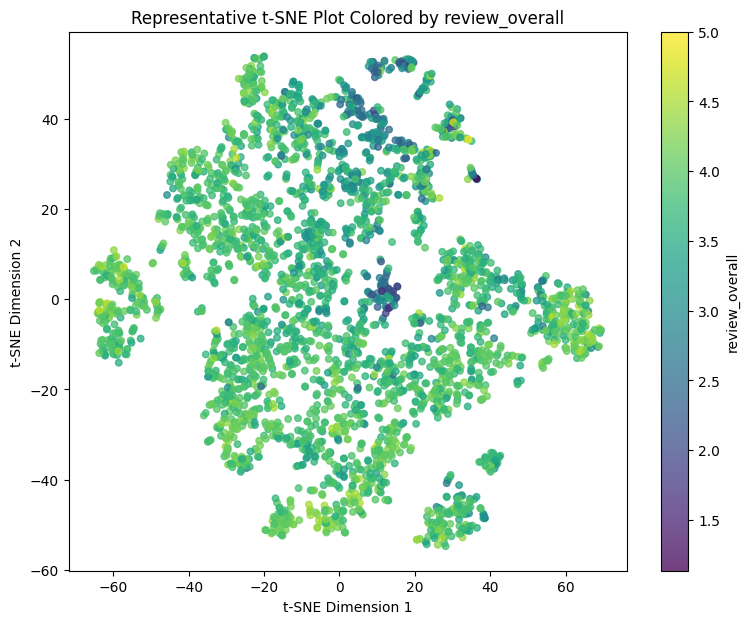

In [13]:
rating_features = [
    'review_aroma', 'review_appearance', 'review_palate',
    'review_taste', 'review_overall'
]

for col in rating_features:
    if col in df_tsne.columns:
        plot_tsne_by_numeric_attribute(df_tsne, col)

**Number of reviews**

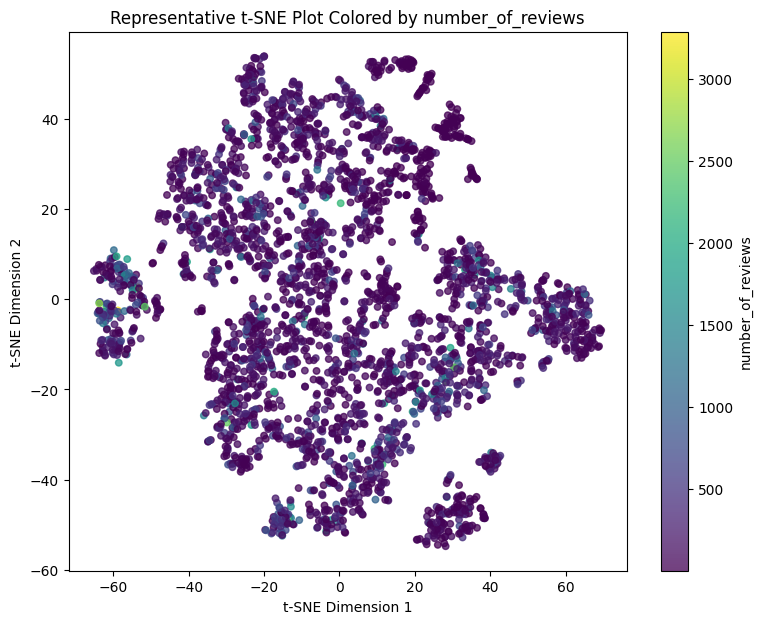

In [14]:
if "number_of_reviews" in df_tsne.columns:
    plot_tsne_by_numeric_attribute(df_tsne, "number_of_reviews")

To better understand what may be driving the t-SNE clustering structure, I color-coded the representative t-SNE plot by each beer specification and taste-profile attribute. I follows the approach we used in the class, where the same t-SNE plot is colored by different attributes to evaluate whether those attributes are associated with the visual clustering structure.

Overall, the t-SNE structure appears to be strongly associated with several beer attributes, especially Min IBU, Max IBU, Bitter, Hoppy, Sour, Fruits, Spices, Malty, Body, Sweet, Alcohol, and ABV. However, the strength of association is not the same for every variable. Some variables show very clear regional patterns, while others only show weak or localized patterns.

**IBU and bitterness-related structure**

I think the clearest attribute association appears in Min IBU, Max IBU, Bitter, and Hoppy. These variables show similar patterns across the t-SNE map. Higher values appear mainly on the left side and lower-left region of the plot, while lower values appear more strongly on the right side, especially the far-right cluster. This suggests that one major source of clustering structure is the difference between beers with stronger bitterness/hop characteristics and beers with lower bitterness/hoppiness.

The Min IBU and Max IBU plots show especially strong separation. The far-left group has very high IBU values, and the lower-central/lower-left areas also show relatively high IBU values. This indicates that t-SNE is grouping beers partly according to bitterness intensity. The Bitter and Hoppy plots support the same interpretation because the high-value regions overlap with the high-IBU regions. As a result, beers with high bitterness and hop-forward profiles appear to form meaningful regions in the t-SNE space.

**Sour and fruit-related structure**

Another clear pattern appears in Sour and Fruits. The far-right cluster has noticeably high sourness and fruitiness, especially compared with the central and upper regions. This suggests that the right-side group may represent beers with more sour or fruit-forward flavor profiles. The Fruits plot also shows elevated values in the right-side cluster and parts of the lower-central region, while the Sour plot is especially concentrated on the far-right side. This indicates that sourness is one of the strongest attributes separating the right-side cluster from the rest of the dataset.

**Malty, body, and sweetness structure**

The attributes Malty, Body, and Sweet also show visible regional patterns. Higher Malty values appear mostly in the lower-left and lower-central regions of the plot. Body shows a similar pattern, with higher values concentrated in the lower-left/lower-middle part of the t-SNE plot. Sweet also has higher values in the lower-central region, although the pattern is slightly more spread out than Malty or Body.

This suggests that another important t-SNE region may represent fuller-bodied, sweeter, and more malt-forward beers. These beers are not always completely separated from other groups, but the color gradients indicate that they contribute to the overall clustering structure.

**Alcohol and ABV structure**

The Alcohol and ABV plots show a related but more localized pattern. Higher alcohol values appear mainly in the lower-central region, and ABV is also elevated in this same general area. However, compared with IBU, Bitter, Hoppy, Sour, and Fruits, the ABV pattern is less spread across the full t-SNE map. This suggests that alcohol content contributes to the clustering structure, but it may not be the main factor separating all groups. Instead, it seems especially important for identifying a smaller region of stronger or higher-alcohol beers.

**Astringency, spices, and salty structure**

Astringency shows a strong localized association, especially on the far-right side of the plot. This overlaps somewhat with the sour and fruit-forward region, suggesting that some beers in that group may also have higher astringency. Spices also show a very clear localized pattern, with the highest values concentrated in the lower-right group. This suggests that the lower-right cluster may represent a more spice-forward subgroup.

In contrast, Salty does not appear to be strongly associated with the overall t-SNE structure. Most points have low salty values, and only a few isolated observations show high salty values. Because the high values are not spread across a full visible cluster, salty does not seem to be a major driver of the clustering pattern.